In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [2]:
url = "https://books.toscrape.com/"
response = requests.get(url)
print(response.status_code)

200


In [3]:
soup = BeautifulSoup(response.text,"html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [4]:
first_book = soup.select_one("article.product_pod h3 a")

print(first_book["title"])

A Light in the Attic


In [5]:
books = soup.select("article.product_pod h3 a")

for book in books:
    print(book["title"])

A Light in the Attic
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History of Humankind
The Requiem Red
The Dirty Little Secrets of Getting Your Dream Job
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
The Black Maria
Starving Hearts (Triangular Trade Trilogy, #1)
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Rip it Up and Start Again
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Olio
Mesaerion: The Best Science Fiction Stories 1800-1849
Libertarianism for Beginners
It's Only the Himalayas


In [6]:
books_data = []

for book in soup.select("article.product_pod"):
    title = book.h3.a["title"]
    price = book.select_one(".price_color").text.strip()
    
    rating_class = book.select_one("p.star-rating")["class"]
    rating = rating_class[-1]

    books_data.append({
        "Title": title,
        "Price": price,
        "Rating": rating
    })

    print(books_data[:5])

[{'Title': 'A Light in the Attic', 'Price': 'Â£51.77', 'Rating': 'Three'}]
[{'Title': 'A Light in the Attic', 'Price': 'Â£51.77', 'Rating': 'Three'}, {'Title': 'Tipping the Velvet', 'Price': 'Â£53.74', 'Rating': 'One'}]
[{'Title': 'A Light in the Attic', 'Price': 'Â£51.77', 'Rating': 'Three'}, {'Title': 'Tipping the Velvet', 'Price': 'Â£53.74', 'Rating': 'One'}, {'Title': 'Soumission', 'Price': 'Â£50.10', 'Rating': 'One'}]
[{'Title': 'A Light in the Attic', 'Price': 'Â£51.77', 'Rating': 'Three'}, {'Title': 'Tipping the Velvet', 'Price': 'Â£53.74', 'Rating': 'One'}, {'Title': 'Soumission', 'Price': 'Â£50.10', 'Rating': 'One'}, {'Title': 'Sharp Objects', 'Price': 'Â£47.82', 'Rating': 'Four'}]
[{'Title': 'A Light in the Attic', 'Price': 'Â£51.77', 'Rating': 'Three'}, {'Title': 'Tipping the Velvet', 'Price': 'Â£53.74', 'Rating': 'One'}, {'Title': 'Soumission', 'Price': 'Â£50.10', 'Rating': 'One'}, {'Title': 'Sharp Objects', 'Price': 'Â£47.82', 'Rating': 'Four'}, {'Title': 'Sapiens: A Brief

In [8]:
df = pd.DataFrame(all_books)

In [12]:
df["Price"] = df["Price"].str.extract(r"(\d+\.\d+)").astype(float)
df.head()

,Title,Price,Rating,availability
0,A Light in the Attic,51.77,Three,In stock
1,Tipping the Velvet,53.74,One,In stock
2,Soumission,50.10,One,In stock
3,Sharp Objects,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock


In [7]:
all_books = []

for page in range(1,51):
    url =  f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)

    soup = BeautifulSoup(response.text,"html.parser")

    for book in soup.select("article.product_pod"):

        title = book.h3.a["title"]
        price = book.select_one(".price_color").text.strip() 
        rating = book.select_one("p.star-rating")["class"][-1]
        availability = book.select_one(".availability").get_text("", strip = True)

        all_books.append({
                    "Title": title,
                    "Price": price,
                    "Rating": rating,
                    "availability": availability
                })

print("Totals books scraped:",len(all_books))


        

Totals books scraped: 1000


In [13]:
print("Total books:", len(all_books))

Total books: 1000


In [14]:
print(df["Price"].head(10))

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
5    22.65
6    33.34
7    17.93
8    22.60
9    52.15
Name: Price, dtype: float64


In [15]:
df.shape

(1000, 4)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1000 non-null   str    
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   str    
 3   availability  1000 non-null   str    
dtypes: float64(1), str(3)
memory usage: 31.4 KB


In [17]:
df.isnull().sum()

Title           0
Price           0
Rating          0
availability    0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [20]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)
df.head(10)

,Title,Price,Rating,availability
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock
5,The Requiem Red,22.65,1,In stock
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,In stock
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,In stock
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,In stock
9,The Black Maria,52.15,1,In stock


In [21]:
print("Average Price:",df["Price"].mean())
print("Highest Price:",df["Price"].max())
print("Lowest Price:",df["Price"].min())
print("Average Rating:",df["Rating"].mean())


Average Price: 35.07035
Highest Price: 59.99
Lowest Price: 10.0
Average Rating: 2.923


In [22]:
df["Rating"].value_counts().sort_index()

Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64

In [23]:
df.groupby("Rating")["Price"].mean().round(2)

Rating
1    34.56
2    34.81
3    34.69
4    36.09
5    35.37
Name: Price, dtype: float64

In [24]:
df.sort_values("Price", ascending=False).head(10)

,Title,Price,Rating,availability
648,The Perfect Play (Play by Play #1),59.99,3,In stock
617,Last One Home (New Beginnings #1),59.98,3,In stock
860,Civilization and Its Discontents,59.95,2,In stock
560,The Barefoot Contessa Cookbook,59.92,5,In stock
366,The Diary of a Young Girl,59.90,3,In stock
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71,3,In stock
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,1,In stock
387,Boar Island (Anna Pigeon #19),59.48,3,In stock
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45,4,In stock
393,The Improbability of Love,59.45,1,In stock


In [25]:
df.sort_values("Price", ascending=True).head(10)

,Title,Price,Rating,availability
638,An Abundance of Katherines,10.00,5,In stock
501,The Origin of Species,10.01,4,In stock
716,The Tipping Point: How Little Things Can Make ...,10.02,2,In stock
84,Patience,10.16,3,In stock
302,Greek Mythic History,10.23,5,In stock
558,The Fellowship of the Ring (The Lord of the Ri...,10.27,2,In stock
479,History of Beauty,10.29,4,In stock
242,The Lucifer Effect: Understanding How Good Peo...,10.40,1,In stock
434,"NaNo What Now? Finding your editing process, r...",10.41,4,In stock
274,Pet Sematary,10.56,3,In stock


In [26]:
df[df["Rating"] == 5][["Title","Price","availability"]].head(10)

,Title,Price,availability
4,Sapiens: A Brief History of Humankind,54.23,In stock
12,Set Me Free,17.46,In stock
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,In stock
14,Rip it Up and Start Again,35.02,In stock
23,Chase Me (Paris Nights #2),25.27,In stock
24,Black Dust,34.53,In stock
28,Worlds Elsewhere: Journeys Around Shakespeareâ...,40.30,In stock
30,The Four Agreements: A Practical Guide to Pers...,17.66,In stock
32,The Elephant Tree,23.82,In stock
34,Sophie's World,15.94,In stock


In [27]:
bins = [0,20,30,40,50,60]
labels = ["Below 20", "20-30", "30-40", "40-50", "Above 50"]

df["Price_Range"] = pd.cut(df["Price"], bins = bins, labels=labels)

df["Price_Range"].value_counts().sort_index()

Price_Range
Below 20    196
20-30       207
30-40       194
40-50       205
Above 50    198
Name: count, dtype: int64

In [28]:
df["availability"].value_counts()

availability
In stock    1000
Name: count, dtype: int64

In [29]:
df.columns

Index(['Title', 'Price', 'Rating', 'availability', 'Price_Range'], dtype='str')

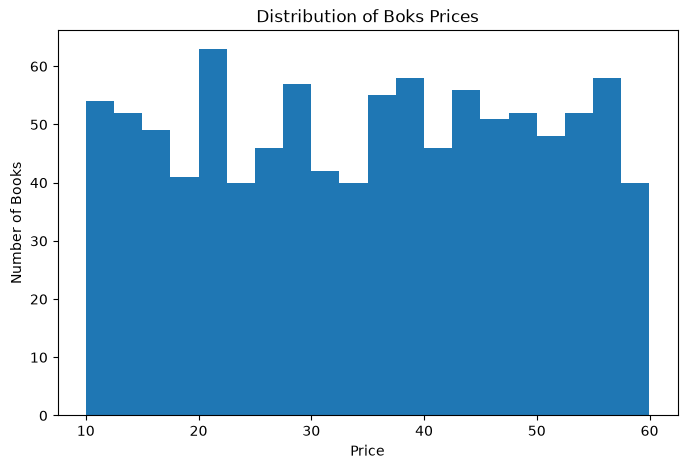

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 5))
plt.hist(df["Price"], bins=20 )
plt.xlabel("Price")
plt.ylabel("Number of Books")
plt.title("Distribution of Boks Prices")
plt.show()
                    

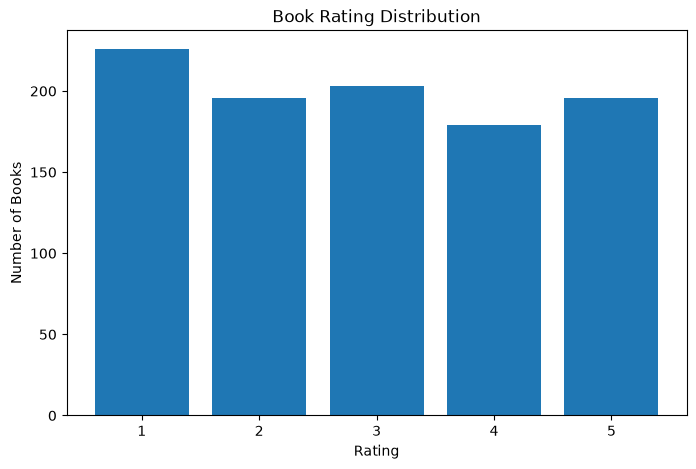

In [31]:
rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize= (8, 5))
plt.bar(rating_counts.index,rating_counts.values)
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Book Rating Distribution")
plt.xticks([1,2,3,4,5])
plt.show()

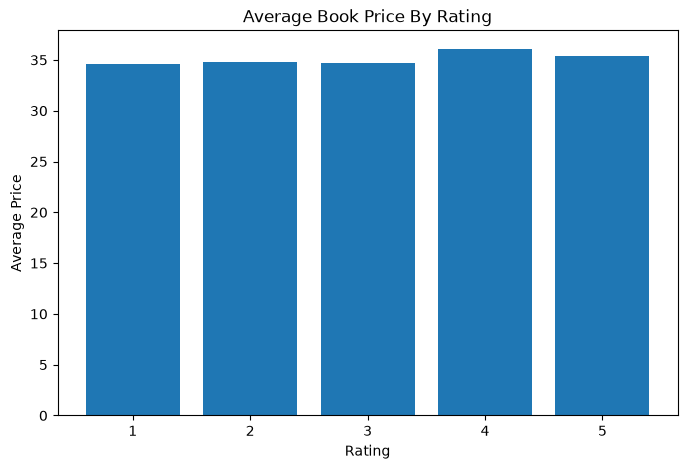

In [32]:
avg_price_rating = df.groupby("Rating")["Price"].mean().round(2)

plt.figure(figsize= (8, 5))
plt.bar(avg_price_rating.index,avg_price_rating.values)
plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.title("Average Book Price By Rating")
plt.xticks([1,2,3,4,5])
plt.show()

In [36]:
df.to_csv("books_scraped.csv",index=False)
df.to_excel("books_scraped.xlsx",index=False)

print("Files Saved Successfully")

Files Saved Successfully


In [1]:
import pymysql
print("pymysql is working")

pymysql is working


In [2]:
from sqlalchemy import create_engine
engine= create_engine("mysql+pymysql://root@localhost:3306/books_analysis")

print("Mysql connection ready!")
    

Mysql connection ready!


In [10]:
import pandas as pd

test_df = pd.read_csv("books_scraped.csv")
print(test_df.shape)
print(test_df.head())

(1000, 5)
                                   Title  Price  Rating availability  \
0                   A Light in the Attic  51.77       3     In stock   
1                     Tipping the Velvet  53.74       1     In stock   
2                             Soumission  50.10       1     In stock   
3                          Sharp Objects  47.82       4     In stock   
4  Sapiens: A Brief History of Humankind  54.23       5     In stock   

  Price_Range  
0    Above 50  
1    Above 50  
2    Above 50  
3       40-50  
4    Above 50  


In [12]:
clean_df = test_df[["Title", "Price", "Rating", "availability"]]
clean_df.to_csv("books_mysql.csv",index=False)
print(clean_df.shape)

(1000, 4)


In [15]:
import pandas as pd

df = pd.read_csv("books_mysql.csv")

with open("books_data.sql", "w", encoding="utf-8") as f:
    f.write("USE books_analysis;\n\n")

    for _, row in df.iterrows():
        title = str(row["Title"]).replace("'", "''")
        price = float(row["Price"])
        rating = int(row["Rating"])
        availability = 1 if str(row["availability"]).strip().lower() == "in stock" else 0

        f.write(
            f"INSERT INTO books (Title, Price, Rating, availability) "
            f"VALUES ('{title}', {price:.2f}, {rating}, {availability});\n"
        )

print("SQL file created!")
print("Total rows:", len(df))

SQL file created!
Total rows: 1000
